* Name: Mustaqueem Alam <br>
* ID  : 2621752 <br>
* ID Serial: 43 <br>
* Course Title : Image Processing <br>
* Course Code : CSC604/CSE420 <br>
* Section :02 <br>

## PROJECT SETUP & LIBRARY IMPORTS

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mount Google Drive
drive.mount('/content/drive')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive


## PATHS & CONFIGURATION

In [2]:
project_path   = '/content/drive/MyDrive/CSE420'
dataset_path   = os.path.join(project_path, 'Ultrasound Fetus Dataset_Classification')
os.makedirs(project_path, exist_ok=True)

In [3]:
BATCH_SIZE  = 32
IMG_SIZE    = (224, 224) # ResNet50 standard input
EPOCHS_TL   = 25        # Phase 1 – transfer learning (frozen base)
EPOCHS_FT   = 15       # Phase 2 – fine-tuning (partially unfrozen)
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'malignant', 'normal']
SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## DATA EXPLORATION & CLASS DISTRIBUTION


--- Scanning Dataset ---

--- Dataset Summary ---
     Split     Class  Count
     train    benign    241
     train malignant    729
     train    normal    242
      test    benign     51
      test malignant    148
      test    normal     50
validation    benign     43
validation malignant    122
validation    normal     43

Total images: 1669


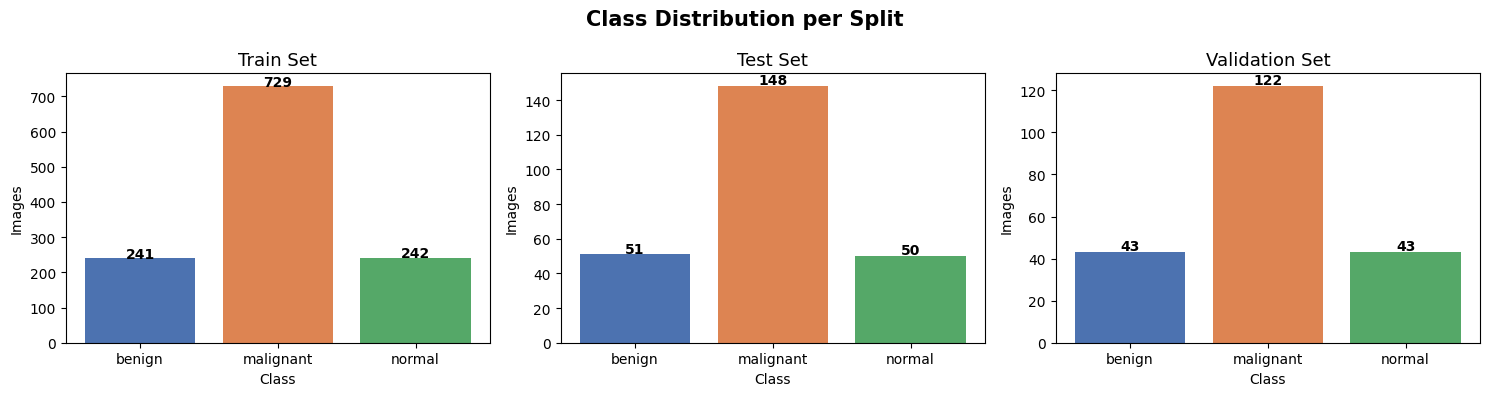

In [4]:
train_dir = os.path.join(dataset_path, 'train')
data_info = []

print("\n--- Scanning Dataset ---")
for split in ['train', 'test', 'validation']:
    split_dir = os.path.join(dataset_path, split)
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.exists(cls_path):
            imgs = [p for p in glob.glob(os.path.join(cls_path, '*.*'))
                    if 'Annotation' not in os.path.basename(p)]
            data_info.append({'Split': split, 'Class': cls, 'Count': len(imgs)})
        else:
            print(f"  Warning – not found: {cls_path}")

df_stats = pd.DataFrame(data_info)
print("\n--- Dataset Summary ---")
print(df_stats.to_string(index=False))
print(f"\nTotal images: {df_stats['Count'].sum()}")

# Plot class distribution per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, split in zip(axes, ['train', 'test', 'validation']):
    sub = df_stats[df_stats['Split'] == split]
    bars = ax.bar(sub['Class'], sub['Count'], color=colors)
    ax.set_title(f'{split.capitalize()} Set', fontsize=13)
    ax.set_xlabel('Class'); ax.set_ylabel('Images')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=10)
plt.suptitle('Class Distribution per Split', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## LOAD DATASETS (No Image Augmentation – Raw Input)

In [5]:
print("\n--- Step 1: Create Padded Images and Save to Drive ---")

# Create padded_image directory structure
padded_image_path = os.path.join(project_path, 'padded_images')
os.makedirs(padded_image_path, exist_ok=True)

# Create subdirectories for each split
for split in ['train', 'test', 'validation']:
    split_path = os.path.join(padded_image_path, split)
    os.makedirs(split_path, exist_ok=True)
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_path, cls)
        os.makedirs(cls_path, exist_ok=True)

print(f"Created padded_images directory structure at: {padded_image_path}")

# Function to save padded images
def save_padded_images(split_name):
    """Save padded images for a given split (train, test, validation)"""
    print(f"\nProcessing {split_name} set...")

    split_dir = os.path.join(dataset_path, split_name)
    saved_count = 0

    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_dir, cls)
        if not os.path.exists(cls_path):
            continue

        # Get all image files
        img_files = [p for p in glob.glob(os.path.join(cls_path, '*.*'))
                    if 'Annotation' not in os.path.basename(p)]

        for img_file in img_files:
            try:
                # Read image
                img = cv2.imread(img_file)
                if img is None:
                    continue

                # Convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Apply square padding
                target_size = 224
                h, w = img.shape[:2]
                scale = target_size / max(h, w)
                new_w, new_h = int(w * scale), int(h * scale)

                img_resized = cv2.resize(img, (new_w, new_h))

                # Create black canvas
                padded = np.zeros((target_size, target_size, 3), dtype=np.uint8)

                # Center the image
                x_offset = (target_size - new_w) // 2
                y_offset = (target_size - new_h) // 2
                padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

                # Convert back to BGR for saving
                padded_bgr = cv2.cvtColor(padded, cv2.COLOR_RGB2BGR)

                # Save padded image
                output_path = os.path.join(padded_image_path, split_name, cls,
                                          os.path.basename(img_file))
                cv2.imwrite(output_path, padded_bgr)
                saved_count += 1

            except Exception as e:
                print(f"  Error processing {img_file}: {e}")

        print(f"  {cls}: {len(img_files)} images processed")

    return saved_count

# Save padded images for all splits
total_saved = 0
for split in ['train', 'test', 'validation']:
    saved = save_padded_images(split)
    total_saved += saved

print(f"\n✓ Total padded images saved: {total_saved}")
print(f"  Location: {padded_image_path}")

# Now load datasets from padded_images directory
print("\n--- Step 2: Load Datasets from Padded Images ---")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(padded_image_path, 'train'),
    label_mode='categorical', image_size=(224, 224),
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(padded_image_path, 'validation'),
    label_mode='categorical', image_size=(224, 224),
    batch_size=BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(padded_image_path, 'test'),
    label_mode='categorical', image_size=(224, 224),
    batch_size=BATCH_SIZE, shuffle=False)

# Apply ResNet preprocessing
train_ds_pp = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds_pp = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds_pp = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

print("All datasets loaded from padded_images directory successfully.")



--- Step 1: Create Padded Images and Save to Drive ---
Created padded_images directory structure at: /content/drive/MyDrive/CSE420/padded_images

Processing train set...
  benign: 241 images processed
  malignant: 729 images processed
  normal: 242 images processed

Processing test set...
  benign: 51 images processed
  malignant: 148 images processed
  normal: 50 images processed

Processing validation set...
  benign: 43 images processed
  malignant: 122 images processed
  normal: 43 images processed

✓ Total padded images saved: 1669
  Location: /content/drive/MyDrive/CSE420/padded_images

--- Step 2: Load Datasets from Padded Images ---
Found 1212 files belonging to 3 classes.
Found 208 files belonging to 3 classes.
Found 249 files belonging to 3 classes.
All datasets loaded from padded_images directory successfully.


## MODEL ARCHITECTURE – PHASE 1 (FROZEN BASE)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

In [7]:
def build_model_phase1():
    """ResNet50 base frozen, custom classification head."""
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(*IMG_SIZE, 3))
    base.trainable = False   # Freeze entire base

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

model, base_model = build_model_phase1()
model.summary()
print(f"\nTrainable params (Phase 1): {model.trainable_variables.__len__()}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,868,611 (91.05 MB)

 Trainable params: 276,803 (1.06 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


Trainable params (Phase 1): 10


## TRAINING – PHASE 1 (TRANSFER LEARNING)

In [8]:
cb_early   = callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                      restore_best_weights=True, verbose=1)
cb_reduce  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                          patience=25, min_lr=1e-7, verbose=1)
cb_ckpt_p1 = callbacks.ModelCheckpoint(
    os.path.join(project_path, 'best_model_phase1.h5'),
    monitor='val_accuracy', save_best_only=True, verbose=1)

print("\n--- Phase 1: Transfer Learning (Frozen Base) ---")
history_p1 = model.fit(
    train_ds_pp, validation_data=val_ds_pp,
    epochs=EPOCHS_TL,
    callbacks=[cb_early, cb_reduce, cb_ckpt_p1],
    verbose=1
)


--- Phase 1: Transfer Learning (Frozen Base) ---
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5086 - loss: 1.2510
Epoch 1: val_accuracy improved from None to 0.50962, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 625ms/step - accuracy: 0.4802 - loss: 1.2595 - val_accuracy: 0.5096 - val_loss: 1.0733 - learning_rate: 0.0010
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5356 - loss: 1.1285
Epoch 2: val_accuracy did not improve from 0.50962
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.5297 - loss: 1.1451 - val_accuracy: 0.4808 - val_loss: 1.0750 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5368 - loss: 1.0989
Epoch 3: val_accuracy improved from 0.50962 to 0.53846, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - accuracy: 0.5347 - loss: 1.1013 - val_accuracy: 0.5385 - val_loss: 1.0771 - learning_rate: 0.0010
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5736 - loss: 1.0365
Epoch 4: val_accuracy did not improve from 0.53846
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.5784 - loss: 1.0340 - val_accuracy: 0.5337 - val_loss: 1.0747 - learning_rate: 0.0010
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6269 - loss: 0.9522
Epoch 5: val_accuracy did not improve from 0.53846
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.5924 - loss: 1.0021 - val_accuracy: 0.5144 - val_loss: 1.0551 - learning_rate: 0.0010
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.6389 - loss: 0.9458
Epoch 6: val_accuracy did not improve from 0.53846
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.6007 - loss: 0.9974 - va


Epoch 8: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 312ms/step - accuracy: 0.6163 - loss: 0.9106 - val_accuracy: 0.5625 - val_loss: 1.0137 - learning_rate: 0.0010
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6248 - loss: 0.8795
Epoch 9: val_accuracy improved from 0.56250 to 0.58173, saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5



Epoch 9: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase1.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.6097 - loss: 0.9124 - val_accuracy: 0.5817 - val_loss: 0.9872 - learning_rate: 0.0010
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6338 - loss: 0.8375
Epoch 10: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.6023 - loss: 0.8795 - val_accuracy: 0.5337 - val_loss: 0.9626 - learning_rate: 0.0010
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6301 - loss: 0.8341
Epoch 11: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - accuracy: 0.6353 - loss: 0.8331 - val_accuracy: 0.4808 - val_loss: 0.9731 - learning_rate: 0.0010
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6706 - loss: 0.8010
Epoch 12: val_accuracy did not improve from 0.58173
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.6427 - loss: 0.823

## EVALUATE PHASE 1 – CURVES, CONFUSION MATRIX, ROC-AUC

In [9]:
def plot_training_curves(history, title_prefix="Phase 1"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history.history['loss']) + 1)

    # Loss curve
    axes[0].plot(ep, history.history['loss'],     'b-o', label='Train Loss',  markersize=4)
    axes[0].plot(ep, history.history['val_loss'], 'r-o', label='Val Loss',    markersize=4)
    axes[0].set_title(f'{title_prefix} – Loss Curve',     fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy curve
    axes[1].plot(ep, history.history['accuracy'],     'b-o', label='Train Acc', markersize=4)
    axes[1].plot(ep, history.history['val_accuracy'], 'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title(f'{title_prefix} – Accuracy Curve', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(project_path, f'curves_{title_prefix.replace(" ", "_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

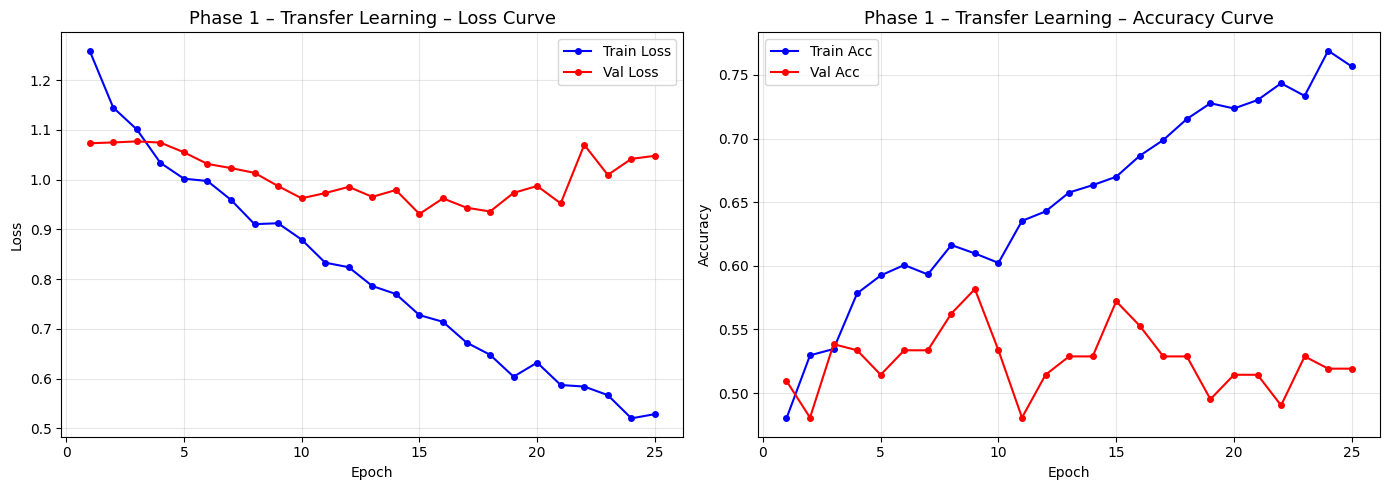


--- Phase 1 – Transfer Learning: Classification Report ---
              precision    recall  f1-score   support

      benign       0.42      0.31      0.36        51
   malignant       0.75      0.86      0.80       148
      normal       0.20      0.16      0.18        50

    accuracy                           0.61       249
   macro avg       0.46      0.45      0.45       249
weighted avg       0.57      0.61      0.59       249



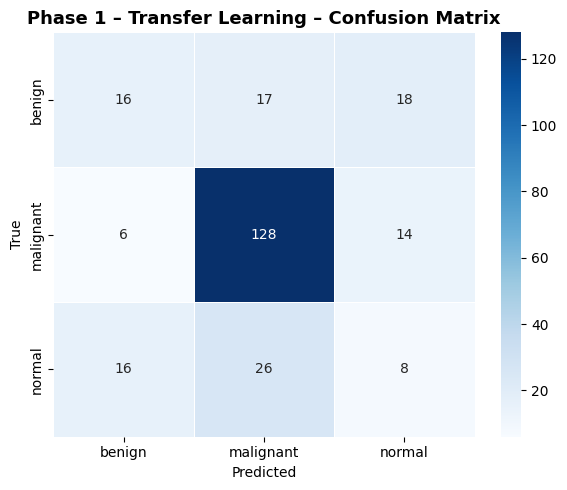

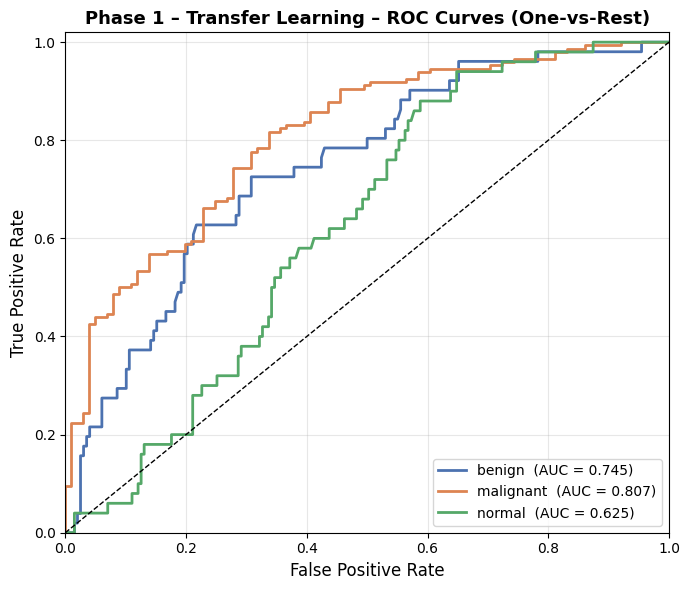

In [10]:
def full_evaluation(model, test_ds_pp, class_names, title_prefix="Phase 1"):
    """Classification report, confusion matrix, and ROC-AUC."""

    # --- Predictions ---
    y_true, y_pred_prob = [], []
    for images, labels in test_ds_pp:
        preds = model.predict(images, verbose=0)
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy())

    y_true      = np.array(y_true)          # (N, 3) one-hot
    y_pred_prob = np.array(y_pred_prob)
    y_true_int  = np.argmax(y_true, axis=1)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)

    # --- Classification Report ---
    print(f"\n--- {title_prefix}: Classification Report ---")
    print(classification_report(y_true_int, y_pred_int, target_names=class_names))

    # --- Confusion Matrix ---
    cm_mat = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title(f'{title_prefix} – Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(project_path, f'cm_{title_prefix.replace(" ", "_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # --- ROC-AUC (One-vs-Rest) ---
    fig, ax = plt.subplots(figsize=(7, 6))
    colors_roc = ['#4C72B0', '#DD8452', '#55A868']
    for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'{title_prefix} – ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_path, f'roc_{title_prefix.replace(" ", "_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return y_true_int, y_pred_int, y_pred_prob


plot_training_curves(history_p1, "Phase 1 – Transfer Learning")
y_true_p1, y_pred_p1, y_prob_p1 = full_evaluation(
    model, test_ds_pp, CLASS_NAMES, "Phase 1 – Transfer Learning")

## PHASE 2 – FINE-TUNING (UNFREEZE TOP LAYERS OF ResNet50)

In [11]:
# For < 2000 images, we unfreeze the last ~30 layers (conv5_block3 + conv4_block6).
# This gives the model enough capacity to adapt without catastrophic forgetting.

In [12]:
print("\n--- Phase 2: Fine-Tuning ---")

# Identify layer names for selective unfreezing
print("\nLast 40 base model layers:")
for i, layer in enumerate(base_model.layers[-40:]):
    print(f"  [{len(base_model.layers)-40+i:3d}] {layer.name:<45} trainable={layer.trainable}")

# Unfreeze from conv5_block1 onwards (last ~30 layers)
UNFREEZE_FROM = 'conv5_block1_1_conv'
unfreeze = False
for layer in base_model.layers:
    if layer.name == UNFREEZE_FROM:
        unfreeze = True
    layer.trainable = unfreeze

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"\nUnfrozen layers in base: {trainable_count} / {len(base_model.layers)}")

# Recompile with a very small learning rate to avoid catastrophic forgetting
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_ckpt_p2 = callbacks.ModelCheckpoint(
    os.path.join(project_path, 'best_model_phase2.h5'),
    monitor='val_accuracy', save_best_only=True, verbose=1)
cb_early2  = callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                      restore_best_weights=True, verbose=1)
cb_reduce2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                          patience=15, min_lr=1e-8, verbose=1)

history_p2 = model.fit(
    train_ds_pp, validation_data=val_ds_pp,
    epochs=EPOCHS_FT,
    callbacks=[cb_early2, cb_reduce2, cb_ckpt_p2],
    verbose=1
)




--- Phase 2: Fine-Tuning ---

Last 40 base model layers:
  [135] conv4_block6_1_relu                           trainable=False
  [136] conv4_block6_2_conv                           trainable=False
  [137] conv4_block6_2_bn                             trainable=False
  [138] conv4_block6_2_relu                           trainable=False
  [139] conv4_block6_3_conv                           trainable=False
  [140] conv4_block6_3_bn                             trainable=False
  [141] conv4_block6_add                              trainable=False
  [142] conv4_block6_out                              trainable=False
  [143] conv5_block1_1_conv                           trainable=False
  [144] conv5_block1_1_bn                             trainable=False
  [145] conv5_block1_1_relu                           trainable=False
  [146] conv5_block1_2_conv                           trainable=False
  [147] conv5_block1_2_bn                             trainable=False
  [148] conv5_block1_2_relu     


Epoch 1: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 665ms/step - accuracy: 0.6064 - loss: 0.9261 - val_accuracy: 0.5529 - val_loss: 0.9589 - learning_rate: 1.0000e-05
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6840 - loss: 0.7160
Epoch 2: val_accuracy did not improve from 0.55288
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.6601 - loss: 0.7500 - val_accuracy: 0.5385 - val_loss: 0.9618 - learning_rate: 1.0000e-05
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7169 - loss: 0.6825
Epoch 3: val_accuracy did not improve from 0.55288
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.7145 - loss: 0.6760 - val_accuracy: 0.5337 - val_loss: 0.9256 - learning_rate: 1.0000e-05
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7419 - loss: 0.6075
Epoch 4: val_accuracy did not improve from 0.55288
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.7203 - loss:


Epoch 5: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - accuracy: 0.7335 - loss: 0.5814 - val_accuracy: 0.6058 - val_loss: 0.8710 - learning_rate: 1.0000e-05
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7709 - loss: 0.5385
Epoch 6: val_accuracy improved from 0.60577 to 0.61058, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 6: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.7541 - loss: 0.5450 - val_accuracy: 0.6106 - val_loss: 0.8503 - learning_rate: 1.0000e-05
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.7925 - loss: 0.4951
Epoch 7: val_accuracy improved from 0.61058 to 0.62019, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 7: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 344ms/step - accuracy: 0.7690 - loss: 0.5102 - val_accuracy: 0.6202 - val_loss: 0.8314 - learning_rate: 1.0000e-05
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8055 - loss: 0.4671
Epoch 8: val_accuracy improved from 0.62019 to 0.64904, saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/CSE420/best_model_phase2.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.7838 - loss: 0.4918 - val_accuracy: 0.6490 - val_loss: 0.8286 - learning_rate: 1.0000e-05
Epoch 9/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7733 - loss: 0.4741
Epoch 9: val_accuracy did not improve from 0.64904
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.7574 - loss: 0.4866 - val_accuracy: 0.6442 - val_loss: 0.8111 - learning_rate: 1.0000e-05
Epoch 10/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7853 - loss: 0.4517
Epoch 10: val_accuracy did not improve from 0.64904
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.7698 - loss: 0.4599 - val_accuracy: 0.6202 - val_loss: 0.8091 - learning_rate: 1.0000e-05
Epoch 11/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8118 - loss: 0.4077
Epoch 11: val_accuracy did not improve from 0.64904
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.7888 - 

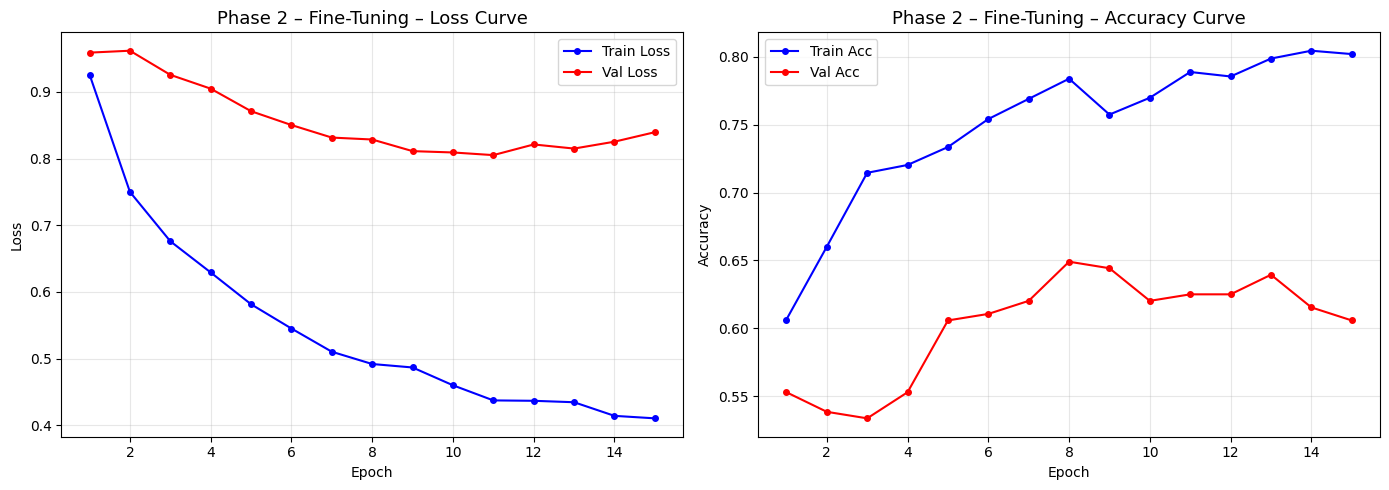


--- Phase 2 – Fine-Tuning: Classification Report ---
              precision    recall  f1-score   support

      benign       0.38      0.39      0.39        51
   malignant       0.84      0.90      0.87       148
      normal       0.15      0.12      0.13        50

    accuracy                           0.64       249
   macro avg       0.46      0.47      0.46       249
weighted avg       0.61      0.64      0.62       249



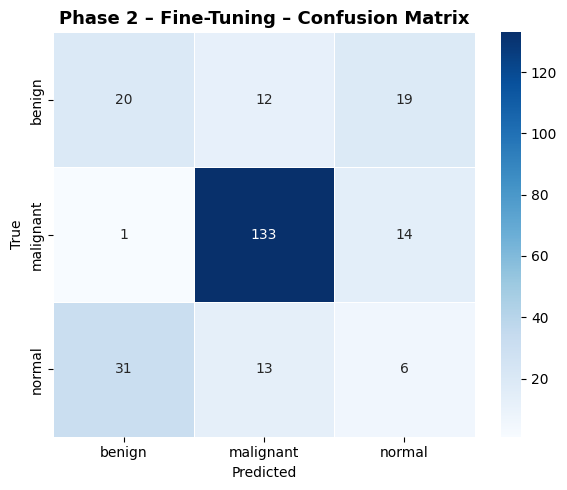

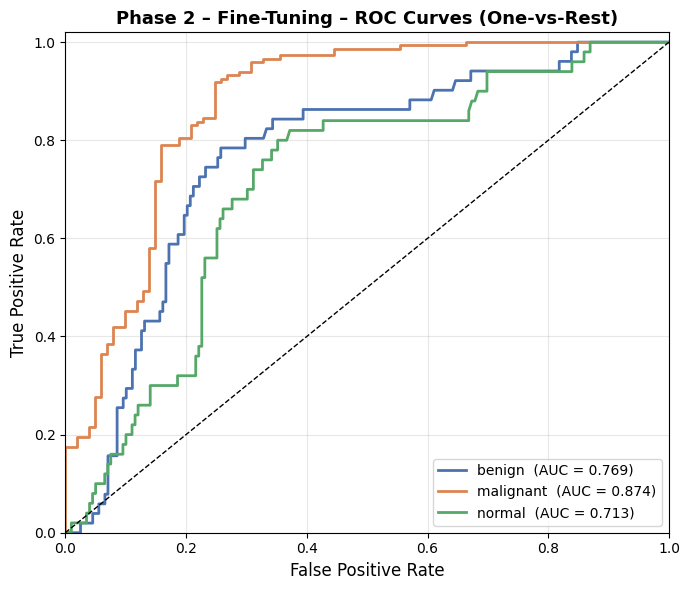

In [13]:
# Evaluate Phase 2
plot_training_curves(history_p2, "Phase 2 – Fine-Tuning")
y_true_p2, y_pred_p2, y_prob_p2 = full_evaluation(
    model, test_ds_pp, CLASS_NAMES, "Phase 2 – Fine-Tuning")


--- Combined Training Curves (Phase 1 & 2) ---


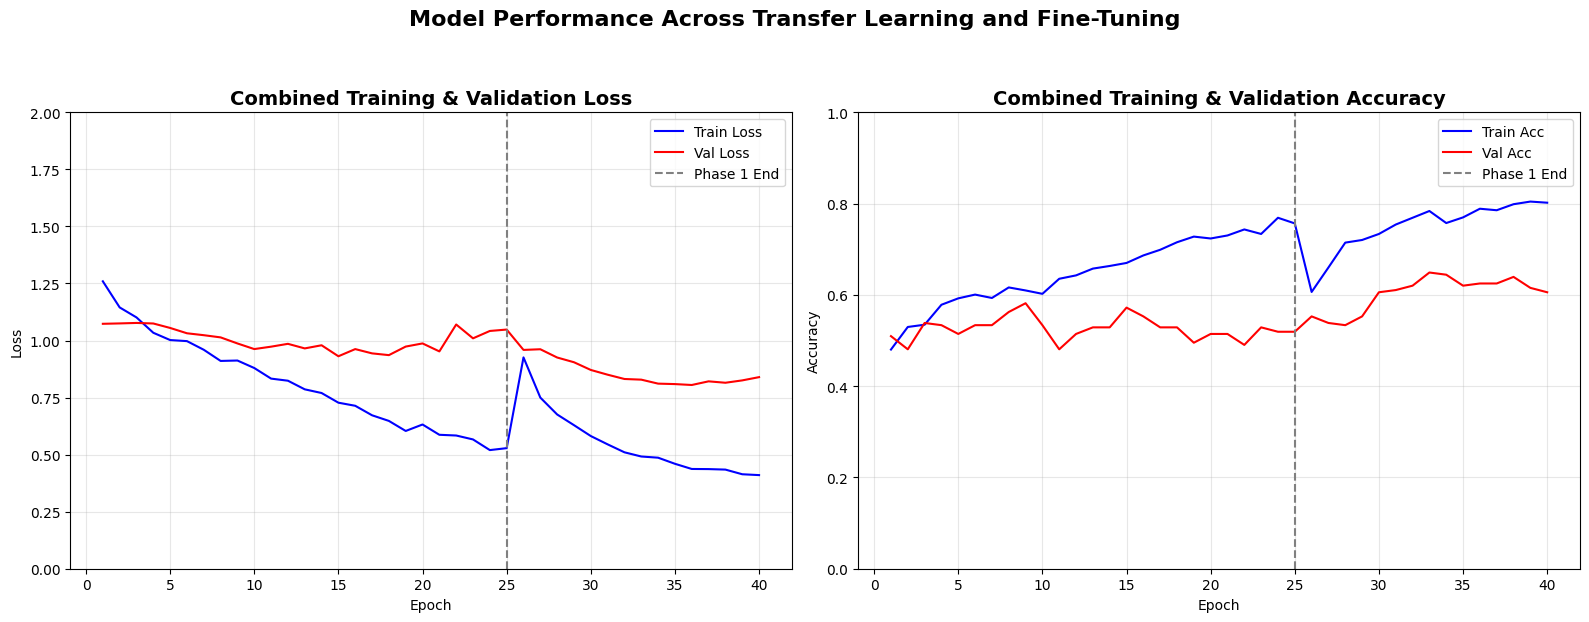

In [14]:
print("\n--- Combined Training Curves (Phase 1 & 2) ---")

# Combine histories
combined_history = {}
for metric in ['loss', 'val_loss', 'accuracy', 'val_accuracy']:
    combined_history[metric] = history_p1.history[metric] + history_p2.history[metric]

epochs_p1 = len(history_p1.history['loss'])
ep = range(1, len(combined_history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Combined Loss Curve ---
axes[0].plot(ep, combined_history['loss'], 'b-', label='Train Loss',  linewidth=1.5)
axes[0].plot(ep, combined_history['val_loss'], 'r-', label='Val Loss',    linewidth=1.5)
axes[0].axvline(x=epochs_p1, color='gray', linestyle='--', label='Phase 1 End')
axes[0].set_title('Combined Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_ylim([0.00, 2]) # Set y-axis limit for loss
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- Combined Accuracy Curve ---
axes[1].plot(ep, combined_history['accuracy'], 'b-', label='Train Acc', linewidth=1.5)
axes[1].plot(ep, combined_history['val_accuracy'], 'r-', label='Val Acc',   linewidth=1.5)
axes[1].axvline(x=epochs_p1, color='gray', linestyle='--', label='Phase 1 End')
axes[1].set_title('Combined Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.00, 1.00]) # Set y-axis limit for accuracy
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model Performance Across Transfer Learning and Fine-Tuning', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(project_path, 'combined_curves_phase1_phase2.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## GRAD-CAM VISUALIZATION

In [15]:
# --- Build Grad-CAM model (use last conv block) ---
grad_cam_layer = 'conv5_block3_out'   # Last ResNet50 conv output

In [16]:
# We need access to the base model inside our functional model.
# Rebuild a sub-model from base_model directly.
grad_model = Model(
    inputs  = base_model.input,
    outputs = [base_model.get_layer(grad_cam_layer).output, base_model.output]
)

In [17]:
def make_gradcam_heatmap(img_array, grad_model, top_model_layers, pred_index=None):
    """
    Compute Grad-CAM heatmap.
    img_array : preprocessed image, shape (1, 224, 224, 3)
    grad_model: model with outputs [last_conv_output, base_output]
    top_model_layers: remaining Dense/GAP layers stacked after the base
    """
    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array)
        tape.watch(conv_outputs)

        # Pass base output through top layers of the full model
        x = base_out
        for lyr in top_model_layers:
            x = lyr(x)
        class_probs = x

        if pred_index is None:
            pred_index = tf.argmax(class_probs[0])
        class_channel = class_probs[:, pred_index]

    grads       = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # (channels,)

    conv_outputs = conv_outputs[0]                          # (H, W, C)
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(raw_img_bgr, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """Resize heatmap and overlay on raw image. Returns overlaid RGB image."""
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(
        cv2.resize(heatmap_uint8, (raw_img_bgr.shape[1], raw_img_bgr.shape[0])),
        colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    raw_rgb       = cv2.cvtColor(raw_img_bgr, cv2.COLOR_BGR2RGB) \
                    if len(raw_img_bgr.shape) == 3 else raw_img_bgr
    overlaid      = np.uint8(alpha * heatmap_color + (1 - alpha) * raw_rgb)
    return overlaid, heatmap_color



base_output_layer_name = base_model.layers[-1].name
top_layers = []
found_base  = False
for lyr in model.layers:
    if found_base:
        top_layers.append(lyr)
    if lyr.name == base_output_layer_name:
        found_base = True

# --- Select 3 images per class from the PADDED TEST SET ---
random.seed(SEED)

padded_test_path = os.path.join(project_path, 'padded_images', 'test')

grad_cam_samples = {}    # {class_name: [img_path, ...]}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(padded_test_path, cls)
    if os.path.exists(cls_dir):
        all_imgs = [p for p in glob.glob(os.path.join(cls_dir, '*.*'))
                    if 'Annotation' not in os.path.basename(p)]
        grad_cam_samples[cls] = random.sample(all_imgs, min(3, len(all_imgs)))
    else:
        print(f"Warning: {cls_dir} not found")
        grad_cam_samples[cls] = []


--- Generating Grad-CAM Visualizations from Padded Test Set ---


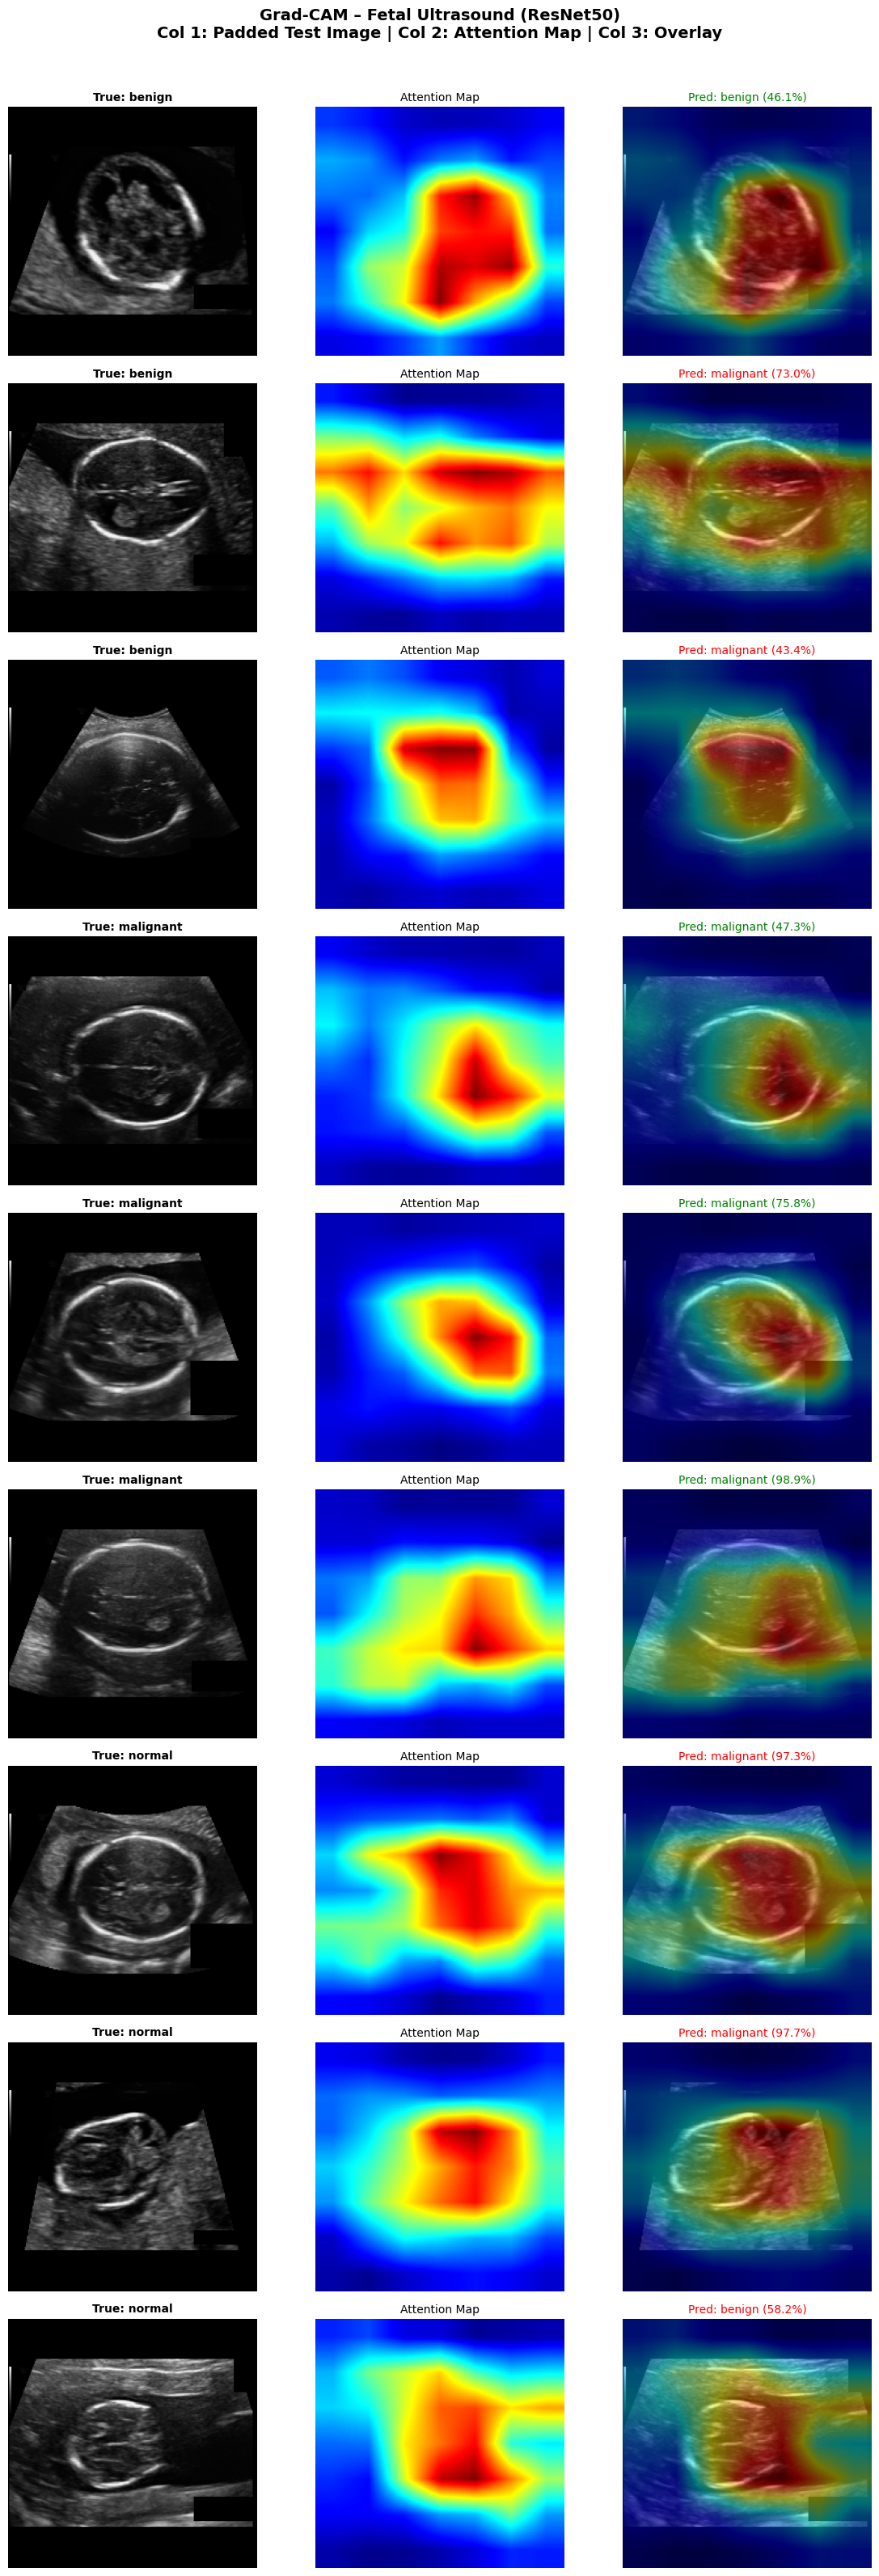

Grad-CAM figure saved.


In [18]:
print("\n--- Generating Grad-CAM Visualizations from Padded Test Set ---")

nrows = sum(len(v) for v in grad_cam_samples.values())  # 9 rows max (3 per class)
fig, axes = plt.subplots(nrows, 3, figsize=(12, nrows * 3.5))
fig.suptitle('Grad-CAM – Fetal Ultrasound (ResNet50)\n'
             'Col 1: Padded Test Image | Col 2: Attention Map | Col 3: Overlay',
             fontsize=14, fontweight='bold', y=1.01)

row = 0
for cls in CLASS_NAMES:
    for img_path in grad_cam_samples[cls]:

        # 1. Load raw image from padded_images/test (BGR via OpenCV)
        raw_bgr = cv2.imread(img_path)
        if raw_bgr is None:
            print(f"Warning: Could not load image {img_path}")
            continue

        raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

        # 2. Preprocess for ResNet50 (image is already 224x224, just normalize)
        img_array = preprocess_input(
                        np.expand_dims(raw_bgr.astype(np.float32), 0))

        # 3. Predict & get Grad-CAM
        pred_probs  = model.predict(img_array, verbose=0)[0]
        pred_class  = np.argmax(pred_probs)
        pred_label  = CLASS_NAMES[pred_class]
        confidence  = pred_probs[pred_class]

        heatmap = make_gradcam_heatmap(img_array, grad_model, top_layers, pred_class)
        overlaid, heatmap_colored = overlay_heatmap(raw_bgr, heatmap)

        # 4. Plot
        ax_raw = axes[row, 0]
        ax_hm  = axes[row, 1]
        ax_ov  = axes[row, 2]

        # Col 1 – Raw padded image
        ax_raw.imshow(raw_rgb)
        ax_raw.set_title(f'True: {cls}', fontsize=10, fontweight='bold')
        ax_raw.axis('off')

        # Col 2 – Heatmap only
        ax_hm.imshow(heatmap_colored)
        ax_hm.set_title('Attention Map', fontsize=10)
        ax_hm.axis('off')

        # Col 3 – Overlay
        ax_ov.imshow(overlaid)
        ax_ov.set_title(f'Pred: {pred_label} ({confidence:.1%})', fontsize=10,
                        color='green' if pred_label == cls else 'red')
        ax_ov.axis('off')

        row += 1

plt.tight_layout()
plt.savefig(os.path.join(project_path, 'gradcam_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM figure saved.")

## SAVE FINAL MODEL

In [19]:
final_model_path = os.path.join(project_path, 'resnet50_fetus_final.h5')
model.save(final_model_path)
print(f"\nFinal model saved to: {final_model_path}")

print("\n=== All done! ===")
print(f"Outputs saved in: {project_path}")
print("  • best_model_phase1.h5")
print("  • best_model_phase2.h5")
print("  • resnet50_fetus_final.h5")
print("  • curves_Phase_1_*.png / curves_Phase_2_*.png")
print("  • cm_Phase_1_*.png / cm_Phase_2_*.png")
print("  • roc_Phase_1_*.png / roc_Phase_2_*.png")
print("  • gradcam_visualization.png")


Final model saved to: /content/drive/MyDrive/CSE420/resnet50_fetus_final.h5

=== All done! ===
Outputs saved in: /content/drive/MyDrive/CSE420
  • best_model_phase1.h5
  • best_model_phase2.h5
  • resnet50_fetus_final.h5
  • curves_Phase_1_*.png / curves_Phase_2_*.png
  • cm_Phase_1_*.png / cm_Phase_2_*.png
  • roc_Phase_1_*.png / roc_Phase_2_*.png
  • gradcam_visualization.png
